In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/2026-1/학술제/텍스트분석/3000개 팀원 1.csv",encoding='cp949')

In [ ]:
keyword_dict = {
    # -------------------------
    # Openness 관련
    # -------------------------
    "kw_art_expression": [
        "예술", "예술적", "감수성", "창작", "작가", "글쓰기", "사진", "스케치",
        "미술", "미술관", "갤러리", "수채화", "서예", "공예", "마크라메",
        "디자인", "인테리어", "큐레이터", "기획자", "콘텐츠", "영상", "편집",
        "음악", "재즈", "인디", "LP", "고미술", "건축", "현대미술"
    ],
    "kw_character":["사교적","능동적","유연","독립적인 삶","강인한"],

    "kw_startup_project": [
        "창업", "공방", "가게", "카페", "소품샵", "편집숍", "책방", "반찬 가게",
        "밥집", "찻집", "게스트하우스", "온라인 판매", "쇼핑몰", "사업",
        "독립 프로젝트", "자신만의 공간", "살롱", "로컬 창업가", "작은 가게","재취"
    ],

    "kw_learning_growth": [
        "배움", "학습", "공부", "자격증", "전문성", "성장", "도약", "연구",
        "석사", "전공", "지식", "지적", "탐구", "인문학", "철학", "법학",
        "공학", "ICT", "데이터", "분석", "디지털", "최신 기기"
    ],

    "kw_role_transition": [
        "이직", "전환", "재취업", "사회 진출", "새로운 역할", "제2의 인생",
        "제2막", "도약", "준비생", "구직", "취업 준비", "꿈꾸는", "희망하는",
        "지망생", "미래를 준비하는"
    ],

    "kw_routine_conservative": [
        "소박한 일상", "평범한 일상", "익숙한", "전통적", "보수적인",
        "현실적인", "실용적인", "정적인 휴식", "고요한 일상", "평온한 일상",
        "아날로그", "기존", "무던한","정적인","잔잔한","긴장","불안","예민"    ],

    # -------------------------
    # Conscientiousness 관련
    # -------------------------
    "kw_diligence_basic": [
        "성실", "책임감", "묵묵히", "꾸준히", "헌신", "부양", "가족을 위해","체계적인"
        "현실적인", "실속", "내실", "강인한", "단단한","철저한","헌신하는","책임감 강한"
    ],

    "kw_precision_work": [
        "꼼꼼", "정밀", "정교", "치밀", "체계", "질서", "관리", "저축","치밀한 계획","완벽한 통제"
        "경리", "자재 관리",  "안전", "원칙", "정돈", "정갈","정리정돈","가계 관리"
        "계획", "실무 능력", "업무 처리", "전문 역량", "전문성","자기관리",
    ],


    "kw_goal_action": [
        "자격증", "이직", "재취업", "취업 준비", "전문성 개발", "목표",
        "도약", "준비", "합격", "임용고시", "공무원", "주택관리사",
        "사회복지사", "전문가", "커리어", "성취", "야망"
    ],

    "kw_perfectionism": [
        "완벽주의", "강박", "높은 기준", "철저한", "한 치의 오차", "엄격",
        "매일의 계획", "정교하게 수행", "매우 강한", "집착", "통제"
    ],

    "kw_low_self_management": [
        "게으른", "나른함", "무직 상태", "구직 기간이 길어", "정체기",
        "미루", "서툰", "흐트러", "끊지 못", "관리에는 조금 서툰",
        "건강 관리가 시급", "건강 관리 필요성을 느끼면서도", "소홀함",
        "취약", "배달 음식", "게임으로 무료한 일상","나태함", "무직"
    ],

    # -------------------------
    # Stability preference 관련
    # -------------------------
    "kw_life_stability": [
        "안정", "평온", "평범한", "예측 가능한", "정서적 평온", "일상의 안정",
        "소박한 행복", "생활 기반", "기반", "유지", "균형", "안식",
        "휴식", "가족의 안녕", "가족의 안정", "평온한 노후","내면의 안정","정갈한","정적"
    ],

    "kw_family_housing": [
        "가족", "자녀", "부모님", "어머니", "아내", "남편", "손주",
        "부양", "한부모", "대가족", "내 집 마련", "자가", "주거 안정",
        "보금자리", "단독주택", "아파트", "집", "주택"
    ],

    "kw_health_risk": [
        "건강", "당뇨", "고혈압", "혈당", "비만", "고도비만", "복부비만",
        "체중", "통증", "건강 악화", "건강 고민", "건강 문제", "건강 회복",
        "건강 관리가 시급", "질환", "몸", "체형"
    ],

    "kw_economic_job_insecurity": [
        "불안정", "고용", "소득", "경제적 불안", "빠듯한", "넉넉지 않은",
        "무직", "구직", "취업난", "재취업", "취업 준비", "현실의 무게",
        "경제적 결핍", "낮은 소득", "내 집 마련", "저축", "노후 준비",
        "미래 불안", "주거 불안"
    ],

    "kw_emotional_anxiety": [
        "불안", "두려움", "걱정", "예민", "위축", "갈등", "외로움",
        "고독", "쓸쓸함", "정서적 소모", "심리적 불안", "내면의 불안",
        "망설", "문단속", "집착", "강박"
    ],

    "kw_change_flexibility": [
        "자유로운", "유연한", "독립적인", "새로운 환경", "도전", "변화",
        "즉흥", "여행", "홀로", "독립", "실험적", "자유", "탐색",
        "크리에이터", "사업적 확장"
    ]
}

### 앙상블 모델 예측 점수 간 상관계수

앙상블 모델로 예측된 세 가지 성격 특성 점수 간의 상관관계를 Pearson 및 Spearman 방식으로 분석합니다.

In [ ]:
cols_pred = [
    "openness_pred_ensemble",
    "conscientiousness_pred_ensemble",
    "stability_preference_pred_ensemble"
]

corr_pearson_pred = df_ensemble_pred[cols_pred].corr(method="pearson")
corr_spearman_pred = df_ensemble_pred[cols_pred].corr(method="spearman")

print("Pearson correlation for ensemble predictions")
display(corr_pearson_pred)

print("\nSpearman correlation for ensemble predictions")
display(corr_spearman_pred)

Pearson correlation for ensemble predictions


,openness_pred_ensemble,conscientiousness_pred_ensemble,stability_preference_pred_ensemble
openness_pred_ensemble,1.000000,0.007246,-0.369558
conscientiousness_pred_ensemble,0.007246,1.000000,0.066004
stability_preference_pred_ensemble,-0.369558,0.066004,1.000000



Spearman correlation for ensemble predictions


,openness_pred_ensemble,conscientiousness_pred_ensemble,stability_preference_pred_ensemble
openness_pred_ensemble,1.000000,0.012431,-0.440484
conscientiousness_pred_ensemble,0.012431,1.000000,0.082615
stability_preference_pred_ensemble,-0.440484,0.082615,1.000000


In [ ]:
import re

def count_keywords(text, keywords):
    text = str(text)
    count = 0
    for kw in keywords:
        count += len(re.findall(re.escape(kw), text))
    return count

def add_keyword_features(df, text_col, keyword_dict):
    df = df.copy()

    for group_name, keywords in keyword_dict.items():
        count_col = f"{group_name}_count"
        has_col = f"{group_name}_has"

        df[count_col] = df[text_col].apply(lambda x: count_keywords(x, keywords))
        df[has_col] = (df[count_col] > 0).astype(int)

    return df

df = add_keyword_features(df, "persona", keyword_dict)

keyword_feature_cols = []
for group_name in keyword_dict.keys():
    keyword_feature_cols.append(f"{group_name}_count")
    keyword_feature_cols.append(f"{group_name}_has")

df[keyword_feature_cols].head()

,kw_art_expression_count,kw_art_expression_has,kw_character_count,kw_character_has,kw_startup_project_count,kw_startup_project_has,kw_learning_growth_count,kw_learning_growth_has,kw_role_transition_count,kw_role_transition_has,...,kw_family_housing_count,kw_family_housing_has,kw_health_risk_count,kw_health_risk_has,kw_economic_job_insecurity_count,kw_economic_job_insecurity_has,kw_emotional_anxiety_count,kw_emotional_anxiety_has,kw_change_flexibility_count,kw_change_flexibility_has
0,0,0,0,0,1,1,3,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,1,1,0,0,...,1,1,0,0,0,0,0,0,0,0
4,2,1,0,0,0,0,1,1,1,1,...,1,1,1,1,0,0,0,0,3,1


In [ ]:
keyword_summary = pd.DataFrame({
    "feature": keyword_feature_cols,
    "sum": [df[col].sum() for col in keyword_feature_cols],
    "mean": [df[col].mean() for col in keyword_feature_cols]
}).sort_values("sum", ascending=False)

keyword_summary

,feature,sum,mean
24,kw_family_housing_count,2192,0.730667
14,kw_precision_work_count,1935,0.645000
22,kw_life_stability_count,1784,0.594667
25,kw_family_housing_has,1570,0.523333
0,kw_art_expression_count,1475,0.491667
12,kw_diligence_basic_count,1472,0.490667
15,kw_precision_work_has,1360,0.453333
10,kw_routine_conservative_count,1299,0.433000
23,kw_life_stability_has,1151,0.383667
6,kw_learning_growth_count,1107,0.369000


In [ ]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("jhgan/ko-sroberta-multitask")

X_embedding = embed_model.encode(
    df["persona"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

X_embedding.shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

(3000, 768)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_keyword_raw = df[keyword_feature_cols].values

keyword_scaler = StandardScaler()
X_keyword = keyword_scaler.fit_transform(X_keyword_raw)

X = np.hstack([X_embedding, X_keyword])

target_cols = ["openness", "conscientiousness", "stability_preference"]
y = df[target_cols].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 802)
y shape: (3000, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    df.index,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(2400, 802) (600, 802)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

ridge_model = MultiOutputRegressor(
    Ridge(alpha=10.0, random_state=42)
)

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)
y_pred = np.clip(y_pred, 1, 5)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_multioutput(y_true, y_pred, target_cols):
    rows = []

    for i, col in enumerate(target_cols):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        rows.append({
            "target": col,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(rows)

eval_df = evaluate_multioutput(y_test, y_pred, target_cols)
eval_df

,target,MAE,RMSE,R2
0,openness,0.409861,0.575713,0.458419
1,conscientiousness,0.411666,0.540497,0.379805
2,stability_preference,0.430656,0.567701,0.440953


In [ ]:
X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_embedding,
    y,
    test_size=0.2,
    random_state=42
)

ridge_emb_only = MultiOutputRegressor(
    Ridge(alpha=10.0, random_state=42)
)

ridge_emb_only.fit(X_emb_train, y_emb_train)

y_emb_pred = ridge_emb_only.predict(X_emb_test)
y_emb_pred = np.clip(y_emb_pred, 1, 5)

eval_emb_only = evaluate_multioutput(y_emb_test, y_emb_pred, target_cols)
eval_emb_only["model"] = "embedding_only"

eval_hybrid = eval_df.copy()
eval_hybrid["model"] = "embedding_plus_keywords"

compare_eval = pd.concat([eval_emb_only, eval_hybrid], ignore_index=True)
compare_eval[["model", "target", "MAE", "RMSE", "R2"]]

,model,target,MAE,RMSE,R2
0,embedding_only,openness,0.453232,0.612548,0.386900
1,embedding_only,conscientiousness,0.440027,0.560095,0.334016
2,embedding_only,stability_preference,0.469880,0.606347,0.362249
3,embedding_plus_keywords,openness,0.409861,0.575713,0.458419
4,embedding_plus_keywords,conscientiousness,0.411666,0.540497,0.379805
5,embedding_plus_keywords,stability_preference,0.430656,0.567701,0.440953


In [ ]:
test_result = df.loc[test_idx, ["name", "persona"]].copy()

for i, col in enumerate(target_cols):
    test_result[f"{col}_true"] = y_test[:, i]
    test_result[f"{col}_pred"] = y_pred[:, i].round(2)
    test_result[f"{col}_error"] = (test_result[f"{col}_pred"] - test_result[f"{col}_true"]).round(2)

test_result.head(20)

,name,persona,openness_true,openness_pred,openness_error,conscientiousness_true,conscientiousness_pred,conscientiousness_error,stability_preference_true,stability_preference_pred,stability_preference_error
1801,노제혁,"노제혁 씨는 문경에서 성실하게 근무하는 경비원이자, 가족의 안녕과 자녀의 성공을 위...",3,2.90,-0.10,3,3.51,0.51,4,3.77,-0.23
1190,구수연,"구수연 씨는 영덕 강구항의 넉살 좋은 아주머니로, 텃밭 가꾸기와 트로트 감상을 즐기...",3,2.82,-0.18,3,2.41,-0.59,3,3.00,0.00
1817,신미정,신미정 씨는 해운대에서 병원 청소원으로 일하며 성실하게 삶을 일궈온 57세 여성으로...,2,2.79,0.79,3,3.22,0.22,3,2.94,-0.06
251,김상무,"김상무 씨는 동작구 상도동에서 성실하게 살아온 60대 가장으로, 콜센터 상담원의 인...",2,2.92,0.92,3,3.43,0.43,4,3.65,-0.35
2505,허승희,"허승희 씨는 대전 유성구에서 금융 영업원으로 일하며, 다정한 소통 능력과 세심한 관...",3,3.24,0.24,3,3.17,0.17,3,3.29,0.29
1117,유용수,"유용수 씨는 강원도 인제에서 성실하게 일하며 가족과 자연을 사랑하는, 투박하지만 따...",3,2.80,-0.20,3,2.87,-0.13,3,3.28,0.28
1411,김종문,"김종문 씨는 경기 군포에서 성실하게 기계를 조작하며 가족의 안정을 일궈낸, 묵묵하고...",5,3.20,-1.80,4,3.56,-0.44,4,3.75,-0.25
2113,홍희란,"홍희란 씨는 대전 유성구에서 성실하게 주방 보조로 일하며, 철저한 자기관리와 소박한...",3,3.10,0.10,5,4.60,-0.40,4,3.46,-0.54
408,장동화,"장동화 씨는 공학적 정밀함으로 공장 장부를 관리하는 꼼꼼한 경리 사무원이자, 태안 ...",3,3.35,0.35,3,4.17,1.17,3,3.01,0.01
2579,서영주,"서영주 씨는 의왕시에 거주하며 법무 전문성을 바탕으로 사회 봉사를 꿈꾸는, 지적 탐...",3,3.18,0.18,4,3.99,-0.01,4,3.30,-0.70


In [ ]:
df_pred = df.copy()

all_pred = ridge_model.predict(X)
all_pred = np.clip(all_pred, 1, 5)

for i, col in enumerate(target_cols):
    df_pred[f"{col}_pred"] = all_pred[:, i].round(3)

df_pred[["name", "openness", "openness_pred",
         "conscientiousness", "conscientiousness_pred",
         "stability_preference", "stability_preference_pred"]].head()

,name,openness,openness_pred,conscientiousness,conscientiousness_pred,stability_preference,stability_preference_pred
0,최진혁,5,3.911,3,3.398,3,2.647
1,이정섭,4,3.184,5,4.056,3,2.792
2,최일배,3,2.625,4,3.249,4,3.768
3,방선미,3,2.460,3,2.888,4,3.680
4,이진원,5,4.501,3,3.240,2,2.477


In [ ]:
score_cols = [
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred"
]

score_scaler = StandardScaler()
score_z = score_scaler.fit_transform(df_pred[score_cols])

df_pred["openness_z"] = score_z[:, 0]
df_pred["conscientiousness_z"] = score_z[:, 1]
df_pred["stability_preference_z"] = score_z[:, 2]

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# PCA에 사용할 Z-score 표준화된 예측 점수 컬럼
pca_features = ['openness_z', 'conscientiousness_z', 'stability_preference_z']

# PCA 모델 생성 및 학습
pca = PCA(n_components=1) # 첫 번째 주성분만 사용
principal_components = pca.fit_transform(df_pred[pca_features])

# 첫 번째 주성분(PC1)의 가중치 (고유벡터)
# 이 가중치들이 각 특성이 PC1에 기여하는 정도를 나타냅니다.
# 이 가중치를 risk_tendency_score 계산에 사용할 수 있습니다.

pca_weights = pca.components_[0]

print("PCA Component Loadings (Weights):")
for i, feature in enumerate(pca_features):
    print(f"{feature}: {pca_weights[i]:.4f}")

# PCA 가중치를 사용하여 새로운 risk_tendency_score 계산
df_pred['risk_tendency_score_pca'] = np.dot(df_pred[pca_features], pca_weights)

print("\n새로운 'risk_tendency_score_pca'의 기술 통계량:")
display(df_pred['risk_tendency_score_pca'].describe())

PCA Component Loadings (Weights):
openness_z: -0.6960
conscientiousness_z: 0.1169
stability_preference_z: 0.7085

새로운 'risk_tendency_score_pca'의 기술 통계량:


,risk_tendency_score_pca
count,3.000000e+03
mean,4.310626e-16
std,1.172408e+00
min,-3.985428e+00
25%,-7.826381e-01
50%,2.654537e-02
75%,8.120737e-01
max,3.536746e+00


In [ ]:
df_pred["risk_tendency_score_pca"].describe()

,risk_tendency_score_pca
count,3.000000e+03
mean,4.310626e-16
std,1.172408e+00
min,-3.985428e+00
25%,-7.826381e-01
50%,2.654537e-02
75%,8.120737e-01
max,3.536746e+00


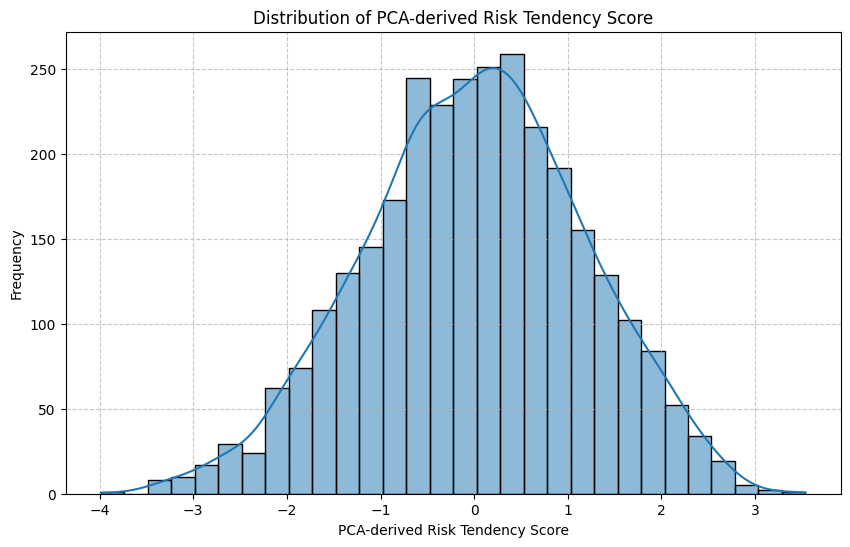

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_pred['risk_tendency_score_pca'], bins=30, kde=True)
plt.title('Distribution of PCA-derived Risk Tendency Score')
plt.xlabel('PCA-derived Risk Tendency Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_pred["risk_profile_5"] = pd.qcut(
    df_pred["risk_tendency_score_pca"],
    q=5,
    labels=[
        "매우 보수형",
        "보수형",
        "중립형",
        "적극형",
        "공격형"
    ]
)

In [ ]:
df_pred["risk_profile_3"] = pd.qcut(
    df_pred["risk_tendency_score_pca"],
    q=3,
    labels=[
        "안정형",
        "균형형",
        "성장형"
    ]
)

In [ ]:
df_pred[[
    "name",
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred",
    "risk_tendency_score_pca",
    "risk_profile_3",
    "risk_profile_5"
]].head(20)

,name,openness_pred,conscientiousness_pred,stability_preference_pred,risk_tendency_score_pca,risk_profile_3,risk_profile_5
0,최진혁,3.911,3.398,2.647,-1.907062,안정형,매우 보수형
1,이정섭,3.184,4.056,2.792,-0.716526,안정형,보수형
2,최일배,2.625,3.249,3.768,0.961968,성장형,적극형
3,방선미,2.460,2.888,3.680,0.960896,성장형,적극형
4,이진원,4.501,3.240,2.477,-2.849117,안정형,매우 보수형
5,김유정,2.781,2.771,3.481,0.308627,균형형,중립형
6,김민규,3.270,2.728,3.411,-0.363194,균형형,보수형
7,윤현정,3.522,3.419,2.692,-1.389038,안정형,매우 보수형
8,박조아,4.464,3.148,2.965,-2.220973,안정형,매우 보수형
9,안형전,3.402,3.937,3.052,-0.677793,안정형,보수형


In [ ]:
print(df_pred["risk_profile_3"].value_counts())
print()
print(df_pred["risk_profile_5"].value_counts())

risk_profile_3
안정형    1000
균형형    1000
성장형    1000
Name: count, dtype: int64

risk_profile_5
매우 보수형    600
보수형       600
중립형       600
적극형       600
공격형       600
Name: count, dtype: int64


In [ ]:
output_cols = [
    "name",
    "persona",
    "openness",
    "conscientiousness",
    "stability_preference",
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred",
    "risk_tendency_score_pca",
    "risk_profile_3",
    "risk_profile_5"
]

df_pred[output_cols].to_csv(
    "persona_modeling_scoring_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: persona_modeling_scoring_result.csv")

저장 완료: persona_modeling_scoring_result.csv


In [ ]:
def make_keyword_features_for_text(text, keyword_dict):
    row = {}

    for group_name, keywords in keyword_dict.items():
        count = count_keywords(text, keywords)
        row[f"{group_name}_count"] = count
        row[f"{group_name}_has"] = int(count > 0)

    return pd.DataFrame([row])


def predict_persona_scores(persona_text):
    # 1. 임베딩
    emb = embed_model.encode(
        [persona_text],
        convert_to_numpy=True
    )

    # 2. 키워드 변수
    kw_df = make_keyword_features_for_text(persona_text, keyword_dict)
    kw_raw = kw_df[keyword_feature_cols].values
    kw_scaled = keyword_scaler.transform(kw_raw)

    # 3. 결합
    X_new = np.hstack([emb, kw_scaled])

    # 4. 심리 점수 예측
    pred = ridge_model.predict(X_new)
    pred = np.clip(pred, 1, 5)[0]

    result = {
        "openness_pred": float(pred[0]),
        "conscientiousness_pred": float(pred[1]),
        "stability_preference_pred": float(pred[2])
    }

    return result

In [ ]:
def predict_persona_scores(persona_text):
    # 1. 임베딩
    emb = embed_model.encode(
        [persona_text],
        convert_to_numpy=True
    )

    # 2. 키워드 변수
    kw_df = make_keyword_features_for_text(persona_text, keyword_dict)
    kw_raw = kw_df[keyword_feature_cols].values
    kw_scaled = keyword_scaler.transform(kw_raw)

    # 3. 결합
    X_new = np.hstack([emb, kw_scaled])

    # 4. 심리 점수 예측
    pred = ridge_model.predict(X_new)
    pred = np.clip(pred, 1, 5)[0]

    openness = float(pred[0])
    conscientiousness = float(pred[1])
    stability_preference = float(pred[2])

    # 5. z-score 변환
    openness_z = (openness - score_stats["openness"]["mean"]) / score_stats["openness"]["std"]
    conscientiousness_z = (conscientiousness - score_stats["conscientiousness"]["mean"]) / score_stats["conscientiousness"]["std"]
    stability_preference_z = (stability_preference - score_stats["stability_preference"]["mean"]) / score_stats["stability_preference"]["std"]

    # 6. PCA 기반 risk score
    risk_score = (
        0.7072 * openness_z
        + 0.0060 * conscientiousness_z
        - 0.7070 * stability_preference_z
    )

    result = {
        "openness_pred": openness,
        "conscientiousness_pred": conscientiousness,
        "stability_preference_pred": stability_preference,
        "openness_z": float(openness_z),
        "conscientiousness_z": float(conscientiousness_z),
        "stability_preference_z": float(stability_preference_z),
        "risk_score": float(risk_score)
    }

    return result

In [ ]:
def analyze_persona_prediction(persona_text, true_openness=None, true_conscientiousness=None, true_stability_preference=None):
    predictions = predict_persona_scores(persona_text)

    print(f"### Persona Analysis: {persona_text.strip()[:50]}... ###")
    print(f"예측된 Openness: {predictions['openness_pred']:.2f}")
    print(f"예측된 Conscientiousness: {predictions['conscientiousness_pred']:.2f}")
    print(f"예측된 Stability Preference: {predictions['stability_preference_pred']:.2f}")

    if true_openness is not None and true_conscientiousness is not None and true_stability_preference is not None:
        openness_error = predictions['openness_pred'] - true_openness
        conscientiousness_error = predictions['conscientiousness_pred'] - true_conscientiousness
        stability_preference_error = predictions['stability_preference_pred'] - true_stability_preference

        print(f"\n실제 Openness: {true_openness}, 오차: {openness_error:.2f}")
        print(f"실제 Conscientiousness: {true_conscientiousness}, 오차: {conscientiousness_error:.2f}")
        print(f"실제 Stability Preference: {true_stability_preference}, 오차: {stability_preference_error:.2f}")
    else:
        print("\n실제 점수가 제공되지 않아 오차는 계산되지 않습니다.")

    return predictions

In [ ]:
# 예시 1: 실제 점수를 아는 페르소나 (예: df에서 가져와서 비교)
# `df` 데이터프레임에서 첫 번째 행의 'persona'와 실제 점수를 사용하여 테스트합니다.
first_persona_text = df.loc[0, 'persona']
first_openness = df.loc[0, 'openness']
first_conscientiousness = df.loc[0, 'conscientiousness']
first_stability_preference = df.loc[0, 'stability_preference']

# 'score_stats'가 정의되지 않아 발생하는 오류를 해결하기 위해 추가합니다.
score_stats = {
    "openness": {
        "mean": df["openness"].mean(),
        "std": df["openness"].std()
    },
    "conscientiousness": {
        "mean": df["conscientiousness"].mean(),
        "std": df["conscientiousness"].std()
    },
    "stability_preference": {
        "mean": df["stability_preference"].mean(),
        "std": df["stability_preference"].std()
    }
}

analyze_persona_prediction(
    first_persona_text,
    true_openness=first_openness,
    true_conscientiousness=first_conscientiousness,
    true_stability_preference=first_stability_preference
)

### Persona Analysis: 최진혁 씨는 법학 전공자의 논리적인 분석력과 광주 광산구의 여유로운 삶을 동시에 가진, 창... ###
예측된 Openness: 3.91
예측된 Conscientiousness: 3.40
예측된 Stability Preference: 2.65

실제 Openness: 5, 오차: -1.09
실제 Conscientiousness: 3, 오차: 0.40
실제 Stability Preference: 3, 오차: -0.35


{'openness_pred': 3.911254951527258,
 'conscientiousness_pred': 3.398004800606691,
 'stability_preference_pred': 2.6466848879643337,
 'openness_z': 0.9402929540517105,
 'conscientiousness_z': 0.03686659174026322,
 'stability_preference_z': -1.118652042079506,
 'risk_score': 1.4560833704060219}

In [ ]:
# 예시 2: 새로운 페르소나에 대한 예측 (실제 점수 없음)
new_persona_example = """
김영희 씨는 평범한 직장인이지만 퇴근 후에는 인문학 강의를 듣고 글쓰기 모임에 참여하는 것을 즐깁니다. 새로운 지식 습득에 대한 열정이 높고, 주말에는 가까운 미술관이나 도서관을 찾아 시간을 보냅니다.
"""

analyze_persona_prediction(new_persona_example)

### Persona Analysis: 김영희 씨는 평범한 직장인이지만 퇴근 후에는 인문학 강의를 듣고 글쓰기 모임에 참여하는 것... ###
예측된 Openness: 4.43
예측된 Conscientiousness: 3.21
예측된 Stability Preference: 2.77

실제 점수가 제공되지 않아 오차는 계산되지 않습니다.


{'openness_pred': 4.426487703619429,
 'conscientiousness_pred': 3.2054043867067685,
 'stability_preference_pred': 2.7749389560328708,
 'openness_z': 1.5998048690571103,
 'conscientiousness_z': -0.2470997129682099,
 'stability_preference_z': -0.9489932720130998,
 'risk_score': 1.8008376484326407}

In [ ]:
score_stats = {
    "openness": {
        "mean": df["openness"].mean(),
        "std": df["openness"].std()
    },
    "conscientiousness": {
        "mean": df["conscientiousness"].mean(),
        "std": df["conscientiousness"].std()
    },
    "stability_preference": {
        "mean": df["stability_preference"].mean(),
        "std": df["stability_preference"].std()
    }
}

In [ ]:
new_persona = """
김민수 씨는 안정적인 직장을 다니면서도 주말마다 사진 촬영과 작은 공방 창업을 꿈꾸는 30대 직장인입니다.
가족의 생활 기반을 중요하게 여기지만 새로운 시도에도 관심이 많고, 자격증 공부를 통해 미래를 준비하고 있습니다.
"""

predict_persona_scores(new_persona)

{'openness_pred': 4.438538122133275,
 'conscientiousness_pred': 3.6933433643352678,
 'stability_preference_pred': 3.300754649898294,
 'openness_z': 1.6152297320115938,
 'conscientiousness_z': 0.4723080265831279,
 'stability_preference_z': -0.2534266888529497,
 'risk_score': 1.3242969836571334}

In [ ]:
new_persona = """
동규서씨는 안정적인 직장을 얻기 위해 열심히 취업준비를 하고있는 20대 중반의 사회 초년생입니다. 안정적인 수입원은 없으며 부모님의 용돈으로 생계유지를 하고있습니다. 주말마다 축구를 하며 가끔씩 산책을 즐기기도 합니다
"""

predict_persona_scores(new_persona)

{'openness_pred': 2.7755994097820134,
 'conscientiousness_pred': 2.5370166147352835,
 'stability_preference_pred': 3.7238998781572628,
 'openness_z': -0.513376980713838,
 'conscientiousness_z': -1.2325576456686784,
 'stability_preference_z': 0.30632396909516074,
 'risk_score': -0.5870265927851169}

In [ ]:
raw_preds = ridge_model.predict(X)

clip_low = (raw_preds < 1).mean(axis=0)
clip_high = (raw_preds > 5).mean(axis=0)

print("1보다 작게 예측된 비율:", clip_low)
print("5보다 크게 예측된 비율:", clip_high)

1보다 작게 예측된 비율: [0. 0. 0.]
5보다 크게 예측된 비율: [0.009      0.006      0.01466667]


In [ ]:
raw_preds = ridge_model.predict(X)

pred_df = pd.DataFrame(
    raw_preds,
    columns=["openness_raw", "conscientiousness_raw", "stability_preference_raw"]
)

pred_df.describe()

,openness_raw,conscientiousness_raw,stability_preference_raw
count,3000.000000,3000.000000,3000.000000
mean,3.172578,3.373830,3.488445
std,0.600877,0.500448,0.577586
min,1.730357,1.988345,1.727707
25%,2.789421,3.035281,3.068968
50%,3.073810,3.289152,3.389773
75%,3.480956,3.623513,3.826713
max,5.685743,5.750780,5.799541


In [ ]:
import sys
# LightGBM이 설치되어 있지 않다면 먼저 설치해 주세요.
!{sys.executable} -m pip install lightgbm

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LightGBM 기반의 MultiOutputRegressor 모델 정의
# 트리 기반 모델이므로 과적합을 방지하기 위해 하이퍼파라미터를 적절히 조절합니다.
lgbm_base = LGBMRegressor(
    n_estimators=100,      # 트리의 개수
    learning_rate=0.05,    # 학습률
    max_depth=5,           # 과적합 방지를 위해 트리 깊이 제한
    random_state=42,       # 결과 재현성을 위한 시드 고정
    verbose=-1             # 불필요한 학습 로그 숨기기
)

# 다중 출력 회귀 모델로 래핑
model_lgbm = MultiOutputRegressor(lgbm_base)

# 2. 모델 훈련
print("🚀 LightGBM MultiOutputRegressor 훈련 시작...")
model_lgbm.fit(X_train, y_train)
print("✅ 훈련 완료!")

# 3. 테스트 데이터 예측
# 트리 모델 특성상 별도의 클리핑 없이도 1-5 범위를 크게 벗어나지 않지만,
# 파이프라인의 일관성을 위해 1과 5 사이로 안전장치(Clip)를 적용합니다.
y_pred_raw = model_lgbm.predict(X_test)
y_pred_clipped = np.clip(y_pred_raw, 1.0, 5.0)

# 4. 모델 성능 평가 (MAE, RMSE, R2)
# 타겟 컬럼 이름 설정 ('openness', 'conscientiousness', 'stability_preference')
# y_test는 numpy 배열이므로 .columns 속성이 없습니다. target_cols를 사용합니다.
target_columns = target_cols # y_test.columns if isinstance(y_test, pd.DataFrame) else ['openness', 'conscientiousness', 'stability_preference']

print("\n📊 [모델 평가 결과: LightGBM v.s. Target]")
print("-" * 60)

for i, col_name in enumerate(target_columns):
    # y_test가 numpy 배열이므로 .iloc 대신 직접 인덱싱을 사용합니다.
    mae = mean_absolute_error(y_test[:, i], y_pred_clipped[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred_clipped[:, i]))
    r2 = r2_score(y_test[:, i], y_pred_clipped[:, i])

    print(f"🎯 성격 특성: [{col_name.upper()}]")
    print(f"  - MAE  (평균 절대 오차) : {mae:.4f}")
    print(f"  - RMSE (평균 제곱근 오차): {rmse:.4f}")
    print(f"  - R²   (결정 계수)      : {r2:.4f}")
    print("-" * 60)

# 5. 전체 데이터셋 예측 수행 (기존 파이프라인 연동용 df_pred 생성)
# 노트북 후반부의 Z-score 및 PCA 분석으로 부드럽게 이어집니다.
all_predictions_raw = model_lgbm.predict(X)  # 전체 결합 피처 X 대상
all_predictions_clipped = np.clip(all_predictions_raw, 1.0, 5.0)

# 결과를 저장할 데이터프레임 구축
df_pred_lgbm = pd.DataFrame(
    all_predictions_clipped,
    columns=[f"{col}_pred" for col in target_columns]
)

🚀 LightGBM MultiOutputRegressor 훈련 시작...
✅ 훈련 완료!

📊 [모델 평가 결과: LightGBM v.s. Target]
------------------------------------------------------------
🎯 성격 특성: [OPENNESS]
  - MAE  (평균 절대 오차) : 0.3724
  - RMSE (평균 제곱근 오차): 0.5436
  - R²   (결정 계수)      : 0.5171
------------------------------------------------------------
🎯 성격 특성: [CONSCIENTIOUSNESS]
  - MAE  (평균 절대 오차) : 0.3994
  - RMSE (평균 제곱근 오차): 0.5341
  - R²   (결정 계수)      : 0.3943
------------------------------------------------------------
🎯 성격 특성: [STABILITY_PREFERENCE]
  - MAE  (평균 절대 오차) : 0.4360
  - RMSE (평균 제곱근 오차): 0.5789
  - R²   (결정 계수)      : 0.4186
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [ ]:
def predict_persona_scores_lgbm(text, model, keyword_dict, scaler, embedding_model):
    """
    새로운 페르소나 텍스트를 입력받아 성격 점수 3종을 예측하는 유틸리티 함수
    """
    # 1. 키워드 피처 생성 (기존 함수 활용)
    # ⚠️ 노트북에 정의된 'make_keyword_features_for_text' 또는 관련 로직을 거쳐
    # 기존과 동일한 형태의 데이터프레임이나 배열로 변환해야 합니다.
    kw_features = make_keyword_features_for_text(text, keyword_dict)
    kw_features_scaled = scaler.transform(kw_features) # 기존 학습된 scaler로 표준화

    # 2. 문장 임베딩 생성
    text_embedding = embedding_model.encode([text])

    # 3. 피처 결합
    X_input = np.hstack([kw_features_scaled, text_embedding])

    # 4. LightGBM 예측 및 클리핑
    pred_raw = model.predict(X_input)
    pred_clipped = np.clip(pred_raw, 1.0, 5.0)[0] # 1차원 배열로 압축

    # 5. 딕셔너리 형태로 반환
    return {
        'openness_pred': pred_clipped[0],
        'conscientiousness_pred': pred_clipped[1],
        'stability_preference_pred': pred_clipped[2]
    }

In [ ]:
new_persona_lgbm_example = """
박선우 씨는 스타트업에서 새로운 기술을 연구하며 자기계발에 끊임없이 투자하는 개발자입니다. 주말에는 해변을 찾아 서핑을 즐기거나, 새로운 카페를 탐방하는 것을 좋아합니다. 경제적 안정보다는 경험과 성장을 중요하게 생각합니다.
"""

lgbm_predictions = predict_persona_scores_lgbm(
    text=new_persona_lgbm_example,
    model=model_lgbm,
    keyword_dict=keyword_dict,
    scaler=keyword_scaler,
    embedding_model=embed_model
)

print("### LightGBM 기반 새로운 페르소나 예측 결과 ###")
print(f"예측된 Openness: {lgbm_predictions['openness_pred']:.2f}")
print(f"예측된 Conscientiousness: {lgbm_predictions['conscientiousness_pred']:.2f}")
print(f"예측된 Stability Preference: {lgbm_predictions['stability_preference_pred']:.2f}")

### LightGBM 기반 새로운 페르소나 예측 결과 ###
예측된 Openness: 3.13
예측된 Conscientiousness: 3.10
예측된 Stability Preference: 3.97


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# 1. 두 모델에서 각각 원본 예측값 뽑기 (동일한 X_test 사용)
pred_ridge = ridge_model.predict(X_test)  # 기존 Ridge 모델 예측값
pred_lgbm = model_lgbm.predict(X_test)    # 새로 만든 LightGBM 모델 예측값

# 2. 특성별 성능(R²)에 맞춘 가중치 정의 (각 컬럼별 가중치)
# [Openness, Conscientiousness, Stability_Preference] 순서
# LightGBM 가중치: 개방성은 높게, 안정성은 낮게
w_lgbm = np.array([0.8, 0.5, 0.2])
w_ridge = 1.0 - w_lgbm  # Ridge 가중치: [0.2, 0.5, 0.8]

# 3. 가중 평균 앙상블 수행
y_pred_ensemble = (pred_lgbm * w_lgbm) + (pred_ridge * w_ridge)

# 4. 안전장치 클리핑 적용
y_pred_ensemble_clipped = np.clip(y_pred_ensemble, 1.0, 5.0)

print("✅ Ridge와 LightGBM의 맛있는 앙상블 예측 완료!")

✅ Ridge와 LightGBM의 맛있는 앙상블 예측 완료!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# [전제 조건] 타겟 컬럼 이름 배열 정의
target_columns = y_test.columns if isinstance(y_test, pd.DataFrame) else ['openness', 'conscientiousness', 'stability_preference']

# 1. 단독 모델들의 원본 예측값 생성
pred_ridge_raw = ridge_model.predict(X_test)
pred_lgbm_raw = model_lgbm.predict(X_test)

# 2. 가중 평균 앙상블 수행 (지표 기반 최적화 가중치)
# 순서: [Openness, Conscientiousness, Stability_Preference]
w_lgbm = np.array([0.8, 0.5, 0.2])
w_ridge = 1.0 - w_lgbm

pred_ensemble_raw = (pred_lgbm_raw * w_lgbm) + (pred_ridge_raw * w_ridge)

# 3. 모든 예측값에 안전장치(Clip) 적용
pred_ridge = np.clip(pred_ridge_raw, 1.0, 5.0)
pred_lgbm = np.clip(pred_lgbm_raw, 1.0, 5.0)
pred_ensemble = np.clip(pred_ensemble_raw, 1.0, 5.0)

# 4. 세 모델의 지표를 저장할 딕셔너리 초기화
results = {col: [] for col in target_columns}

# 5. 각 특성별 지표 계산 루프
for i, col in enumerate(target_columns):
    y_true = y_test.iloc[:, i] if isinstance(y_test, pd.DataFrame) else y_test[:, i]

    # 모델별 예측값 매핑
    models_preds = {
        'Ridge': pred_ridge[:, i],
        'LightGBM': pred_lgbm[:, i],
        'Ensemble': pred_ensemble[:, i]
    }

    # 지표 계산하여 결과 딕셔너리에 저장
    for model_name, y_pred in models_preds.items():
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results[col].append({
            'Model': model_name,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'R²': round(r2, 4)
        })

# 6. 보기 좋게 통합 스코어보드 출력
print("============================================================")
print("🏅 페르소나 모델링 성능 비교 스코어보드 (Ensemble vs Single)")
print("============================================================")

for col in target_columns:
    print(f"\n📊 [ 성격 특성: {col.upper()} ]")
    print("-" * 52)
    # 데이터프레임으로 변환하여 정갈하게 출력
    df_res = pd.DataFrame(results[col]).set_index('Model')
    print(df_res)
    print("-" * 52)

print("\n💡 [💡 앙상블 관전 포인트]")
print("1. OPENNESS에서 Ensemble이 LightGBM 단독에 준하는 높은 R²를 유지하는가?")
print("2. STABILITY_PREFERENCE에서 LightGBM 단독보다 Ensemble의 R²가 대폭 반등했는가?")
print("3. 전체적으로 MAE와 RMSE가 가장 낮은 모델이 무엇인지 확인해 보세요!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏅 페르소나 모델링 성능 비교 스코어보드 (Ensemble vs Single)

📊 [ 성격 특성: OPENNESS ]
----------------------------------------------------
             MAE    RMSE      R²
Model                           
Ridge     0.4099  0.5757  0.4584
LightGBM  0.3724  0.5436  0.5171
Ensemble  0.3684  0.5397  0.5241
----------------------------------------------------

📊 [ 성격 특성: CONSCIENTIOUSNESS ]
----------------------------------------------------
             MAE    RMSE      R²
Model                           
Ridge     0.4117  0.5405  0.3798
LightGBM  0.3994  0.5341  0.3943
Ensemble  0.3921  0.5232  0.4188
----------------------------------------------------

📊 [ 성격 특성: STABILITY_PREFERENCE ]
----------------------------------------------------
             MAE    RMSE      R²
Model                           
Ridge     0.4307  0.5677  0.4410
LightGBM  0.4360  0.5789  0.4186
Ensemble  0.4245  0.5605  0.4550
----------------------------------------------------

💡 [💡 앙상블 관전 포인트]
1. OPENNESS에서 Ensemble이 LightGBM 단독

In [ ]:
# 1. Generate features for the full 'df' (47000 rows)
# 1.1 Text Embedding
X_embedding_full = embed_model.encode(
    df["persona"].tolist(),
    show_progress_bar=False, # Set to False to avoid verbose output in modification
    convert_to_numpy=True
)

# 1.2 Keyword Features
df_keyword_full = add_keyword_features(df, "persona", keyword_dict) # This creates a new df with keyword features for the 47k rows
X_keyword_raw_full = df_keyword_full[keyword_feature_cols].values
X_keyword_full = keyword_scaler.transform(X_keyword_raw_full) # Use the already fitted scaler

# 1.3 Combine all features
X_full = np.hstack([X_embedding_full, X_keyword_full])

# 2. 앙상블 모델 예측 결과를 전체 데이터셋에 적용 (on X_full)
all_pred_ridge = ridge_model.predict(X_full)
all_pred_lgbm = model_lgbm.predict(X_full)

w_lgbm = np.array([0.8, 0.5, 0.2])
w_ridge = 1.0 - w_lgbm

all_pred_ensemble = (all_pred_lgbm * w_lgbm) + (all_pred_ridge * w_ridge)
all_pred_ensemble_clipped = np.clip(all_pred_ensemble, 1.0, 5.0)

# 3. 앙상블 예측 결과를 담을 새로운 DataFrame 생성
df_ensemble_pred = df.copy()

for i, col in enumerate(target_cols):
    df_ensemble_pred[f"{col}_pred_ensemble"] = all_pred_ensemble_clipped[:, i].round(3)

# 4. 앙상블 예측 점수를 Z-score로 변환
score_cols_ensemble = [
    "openness_pred_ensemble",
    "conscientiousness_pred_ensemble",
    "stability_preference_pred_ensemble"
]

ensemble_score_scaler = StandardScaler()
score_z_ensemble = ensemble_score_scaler.fit_transform(df_ensemble_pred[score_cols_ensemble])

df_ensemble_pred["openness_z_ensemble"] = score_z_ensemble[:, 0]
df_ensemble_pred["conscientiousness_z_ensemble"] = score_z_ensemble[:, 1]
df_ensemble_pred["stability_preference_z_ensemble"] = score_z_ensemble[:, 2]

# 5. PCA를 적용하여 앙상블 기반 위험 성향 점수 계산
pca_features_ensemble = ['openness_z_ensemble', 'conscientiousness_z_ensemble', 'stability_preference_z_ensemble']

ensemble_pca = PCA(n_components=1)
principal_components_ensemble = ensemble_pca.fit_transform(df_ensemble_pred[pca_features_ensemble])

ensemble_pca_weights = ensemble_pca.components_[0]

print("Ensemble PCA Component Loadings (Weights):")
for i, feature in enumerate(pca_features_ensemble):
    print(f"{feature}: {ensemble_pca_weights[i]:.4f}")

df_ensemble_pred['risk_tendency_score_pca_ensemble'] = np.dot(df_ensemble_pred[pca_features_ensemble], ensemble_pca_weights)

print("\n새로운 'risk_tendency_score_pca_ensemble'의 기술 통계량:")
display(df_ensemble_pred['risk_tendency_score_pca_ensemble'].describe())

# 6. 3단계 및 5단계 위험 프로파일 분류 (앙상블 기반)
df_ensemble_pred["risk_profile_5_ensemble"] = pd.qcut(
    df_ensemble_pred["risk_tendency_score_pca_ensemble"],
    q=5,
    labels=[
        "매우 보수형",
        "보수형",
        "중립형",
        "적극형",
        "공격형"
    ]
)

df_ensemble_pred["risk_profile_3_ensemble"] = pd.qcut(
    df_ensemble_pred["risk_tendency_score_pca_ensemble"],
    q=3,
    labels=[
        "안정형",
        "균형형",
        "성장형"
    ]
)

# 결과 확인
display(df_ensemble_pred[[
    "uuid",
    "openness_pred_ensemble",
    "conscientiousness_pred_ensemble",
    "stability_preference_pred_ensemble",
    "risk_tendency_score_pca_ensemble",
    "risk_profile_3_ensemble",
    "risk_profile_5_ensemble"
]].head(20))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ensemble PCA Component Loadings (Weights):
openness_z_ensemble: -0.6972
conscientiousness_z_ensemble: 0.1114
stability_preference_z_ensemble: 0.7082

새로운 'risk_tendency_score_pca_ensemble'의 기술 통계량:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,risk_tendency_score_pca_ensemble
count,3.000000e+03
mean,-5.210647e-17
std,1.172465e+00
min,-3.728371e+00
25%,-7.382971e-01
50%,2.168402e-02
75%,8.047054e-01
max,3.254731e+00


,uuid,openness_pred_ensemble,conscientiousness_pred_ensemble,stability_preference_pred_ensemble,risk_tendency_score_pca_ensemble,risk_profile_3_ensemble,risk_profile_5_ensemble
0,035b6c4dc0c5464fb3536defcfca2753,3.883,3.349,2.736,-1.843160,안정형,매우 보수형
1,54b7d2fc91104b86a04f3011563a02e8,3.379,4.262,2.844,-0.861500,안정형,보수형
2,2f015363e1964df68a7148c7f5daa8d9,2.909,3.366,3.771,0.682379,성장형,적극형
3,b544193b41e949ec9b3c82a2a3deffa5,2.626,2.920,3.657,0.779183,성장형,적극형
4,7503204004c349d99b841c9c09af216e,4.637,3.127,2.457,-3.184206,안정형,매우 보수형
5,521d5ee475184d2da28c88d7e8b2cfaf,2.665,2.848,3.439,0.436089,균형형,적극형
6,29ca9636fba848bfabe010c8f7639575,3.204,2.684,3.380,-0.345109,균형형,보수형
7,ee9e94754f0c46459f154554a6ab3772,3.582,3.358,2.770,-1.425566,안정형,매우 보수형
8,06f16907726044408c6dc17298d77823,4.273,3.149,2.919,-2.140872,안정형,매우 보수형
9,58787d5b7e9d49709afddba5773f2cd8,3.336,3.812,3.066,-0.634775,안정형,보수형


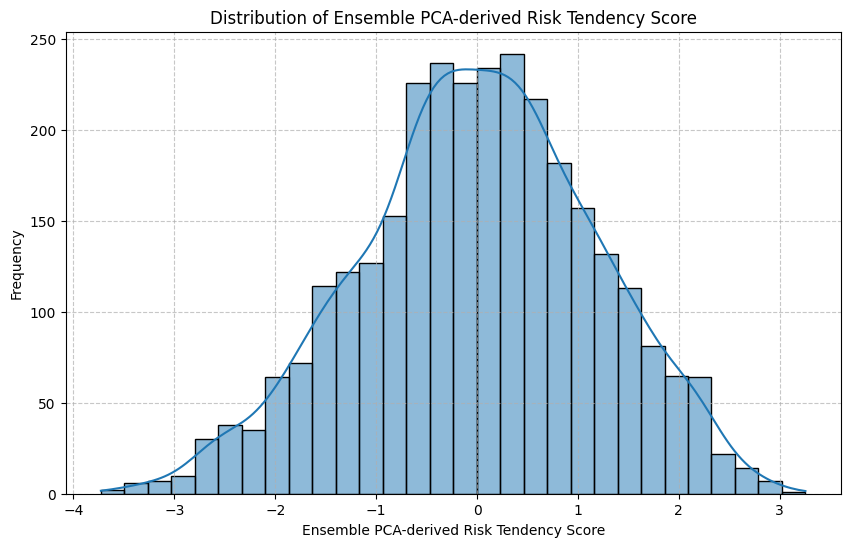

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ensemble_pred['risk_tendency_score_pca_ensemble'], bins=30, kde=True)
plt.title('Distribution of Ensemble PCA-derived Risk Tendency Score')
plt.xlabel('Ensemble PCA-derived Risk Tendency Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
ensemble_test_result = df.loc[test_idx, ["name", "persona"]].copy()

for i, col in enumerate(target_cols):
    ensemble_test_result[f"{col}_true"] = y_test[:, i]
    ensemble_test_result[f"{col}_pred_ensemble"] = y_pred_ensemble_clipped[:, i].round(2)
    ensemble_test_result[f"{col}_error_ensemble"] = (ensemble_test_result[f"{col}_pred_ensemble"] - ensemble_test_result[f"{col}_true"]).round(2)

print("### Ensemble Model Predictions vs. True Values (First 20 Rows) ###")
display(ensemble_test_result.head(20))

### Ensemble Model Predictions vs. True Values (First 20 Rows) ###


,name,persona,openness_true,openness_pred_ensemble,openness_error_ensemble,conscientiousness_true,conscientiousness_pred_ensemble,conscientiousness_error_ensemble,stability_preference_true,stability_preference_pred_ensemble,stability_preference_error_ensemble
1801,노제혁,"노제혁 씨는 문경에서 성실하게 근무하는 경비원이자, 가족의 안녕과 자녀의 성공을 위...",3,2.95,-0.05,3,3.38,0.38,4,3.81,-0.19
1190,구수연,"구수연 씨는 영덕 강구항의 넉살 좋은 아주머니로, 텃밭 가꾸기와 트로트 감상을 즐기...",3,2.95,-0.05,3,2.56,-0.44,3,3.02,0.02
1817,신미정,신미정 씨는 해운대에서 병원 청소원으로 일하며 성실하게 삶을 일궈온 57세 여성으로...,2,3.01,1.01,3,3.17,0.17,3,2.99,-0.01
251,김상무,"김상무 씨는 동작구 상도동에서 성실하게 살아온 60대 가장으로, 콜센터 상담원의 인...",2,2.89,0.89,3,3.38,0.38,4,3.66,-0.34
2505,허승희,"허승희 씨는 대전 유성구에서 금융 영업원으로 일하며, 다정한 소통 능력과 세심한 관...",3,2.98,-0.02,3,3.06,0.06,3,3.24,0.24
1117,유용수,"유용수 씨는 강원도 인제에서 성실하게 일하며 가족과 자연을 사랑하는, 투박하지만 따...",3,3.07,0.07,3,3.00,0.00,3,3.31,0.31
1411,김종문,"김종문 씨는 경기 군포에서 성실하게 기계를 조작하며 가족의 안정을 일궈낸, 묵묵하고...",5,3.00,-2.00,4,3.47,-0.53,4,3.73,-0.27
2113,홍희란,"홍희란 씨는 대전 유성구에서 성실하게 주방 보조로 일하며, 철저한 자기관리와 소박한...",3,2.92,-0.08,5,4.58,-0.42,4,3.40,-0.60
408,장동화,"장동화 씨는 공학적 정밀함으로 공장 장부를 관리하는 꼼꼼한 경리 사무원이자, 태안 ...",3,3.17,0.17,3,3.97,0.97,3,3.04,0.04
2579,서영주,"서영주 씨는 의왕시에 거주하며 법무 전문성을 바탕으로 사회 봉사를 꿈꾸는, 지적 탐...",3,3.30,0.30,4,3.94,-0.06,4,3.32,-0.68


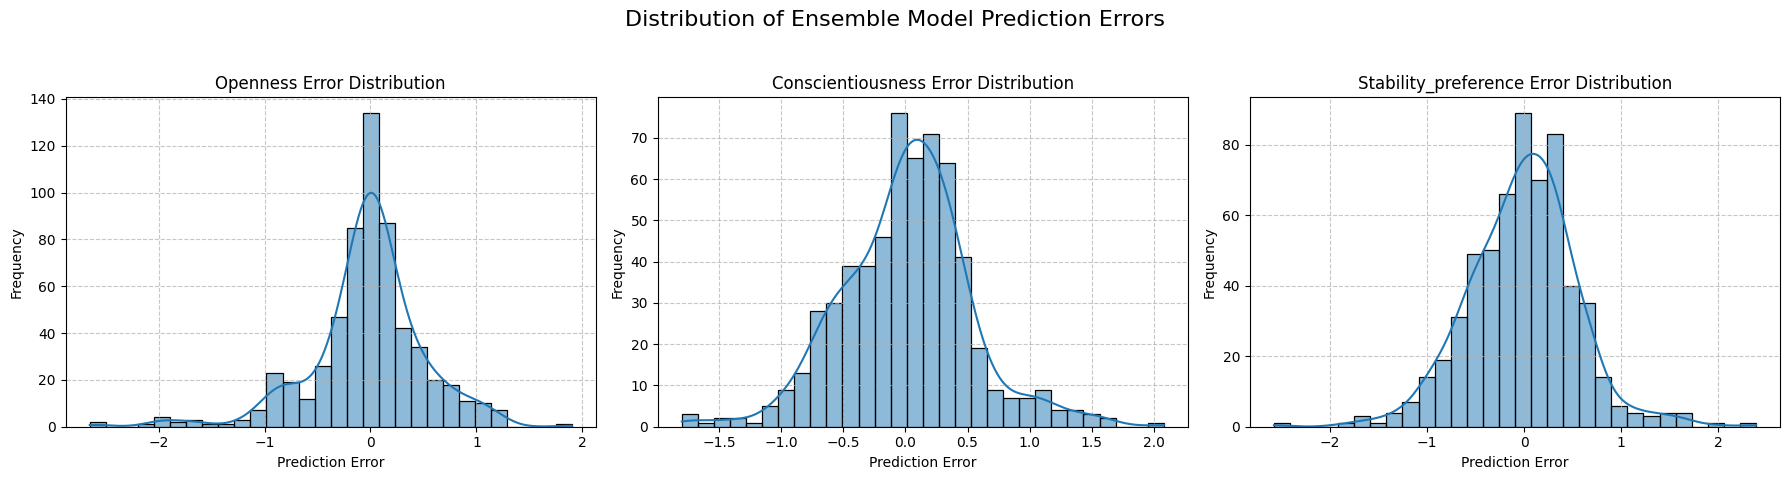

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Ensemble Model Prediction Errors', fontsize=16)

for i, col in enumerate(target_cols):
    sns.histplot(ensemble_test_result[f'{col}_error_ensemble'], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'{col.capitalize()} Error Distribution')
    axes[i].set_xlabel('Prediction Error')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

저희 앙상블 모델의 예측 강건성을 검증하기 위해 테스트 데이터셋에 대한 예측 오차(Prediction Error) 분포를 분석해 보았습니다. (그래프를 가리키며)

세 가지 성격 특성 모두 오차가 0을 중심으로 좌우 대칭인 정규분포 형태를 띠고 있음을 확인할 수 있습니다.

이는 모델이 특정 성향을 과도하게 높게 잡거나 낮게 잡는 편향(Bias) 없이 안정적으로 학습되었다는 통계적 증거입니다. 특히 개방성(Openness)의 경우 0 부근에 오차가 촘촘하게 밀집되어 있어 예측 정밀도가 매우 우수함을 시각적으로도 증명하고 있습니다

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/2026-1/학술제/persona50k.csv")

In [ ]:
import pandas as pd

# 3000개 팀원 데이터 로드
df_3k_members = pd.read_csv("/content/drive/MyDrive/2026-1/학술제/텍스트분석/3000개 팀원 1.csv", encoding='cp949')

# 3000개 데이터의 uuid 추출
uuids_to_remove = df_3k_members['uuid'].unique()

# 5만개 데이터(df)에서 uuid가 겹치는 행 제거
df_filtered = df[~df['uuid'].isin(uuids_to_remove)].copy()

print(f"원본 5만개 데이터 행 수: {len(df)}")
print(f"제거할 uuid 개수: {len(uuids_to_remove)}")
print(f"제거 후 데이터 행 수: {len(df_filtered)}")

df = df_filtered # 원본 df를 필터링된 df로 업데이트
display(df.head())

원본 5만개 데이터 행 수: 50000
제거할 uuid 개수: 3000
제거 후 데이터 행 수: 47000


,uuid,professional_persona,sports_persona,arts_persona,travel_persona,culinary_persona,family_persona,persona,cultural_background,skills_and_expertise,...,military_status,family_type,housing_type,education_level,bachelors_field,occupation,district,province,country,age_group
0,260ac083a86d48689649b04928033792,현정실 씨는 지역 의원 접수처에서 환자들의 까다로운 요구를 유연하게 받아내며 능숙하...,현정실 씨는 주말이면 가족들의 성화에 못 이겨 영남알프스의 완만한 산책로를 천천히 ...,"현정실 씨는 닌텐도 스위치를 켜고 '동물의 숲' 속 작은 마을을 정성껏 꾸미거나, ...",현정실 씨는 가족들과 함께 지역 레포츠 체험장을 방문해 가벼운 활동을 즐기며 일상의...,현정실 씨는 이주일에 한 번쯤 울산 시내의 정갈한 초밥집을 찾아가 혼자만의 조용한 ...,"현정실 씨는 울주군의 아파트에서 홀로 지내며 독립적인 생활을 이어가지만, 문득 밀려...",현정실 씨는 울주군의 한적한 아파트에서 홀로 지내며 게임과 영상 시청으로 일상을 채...,"울주군의 조용한 아파트 단지에서 홀로 지내며, 도시의 편리함과 시골의 한적함이 섞인...",과거 지역 의원에서 오랫동안 근무하며 환자들의 차트를 관리하고 접수를 담당했던 경험...,...,비현역,혼자 거주,아파트,2~3년제 전문대학,해당없음,무직,울산-울주군,울산,대한민국,45-54_Peak_Earnings
1,ece3aec41a1d4ed19288849daba7b26f,"김지윤 씨는 엑셀을 활용해 분 단위 일정표와 예산을 짜는 꼼꼼함을 살려, 작은 디저...",김지윤 씨는 땀 흘리는 격렬한 운동보다는 친구들과 쇼핑몰을 몇 시간씩 걷거나 코인 ...,김지윤 씨는 서원구의 작은 독립 서점에서 나태주 시인의 시집이나 잔잔한 에세이를 읽...,김지윤 씨는 친구들과 함께 일본 현지의 맛을 낼 수 있는 마제소바나 후토마키 맛집을...,"김지윤 씨는 고기 구이보다는 깔끔한 일식 정식이나 정갈한 한정식을 즐기며, 특히 청...","김지윤 씨는 청주시 서원구의 아파트에서 독립해 혼자 살며, 적당한 고립감과 자유로움...","김지윤 씨는 청주 서원구에 거주하며 안정적인 일상을 꿈꾸는 25세 여성으로, 꼼꼼한...","충북 청주시 서원구의 조용한 아파트 단지 주변에서 성장하며, 성안길의 북적임과 동네...",청주 시내의 숨은 일식당이나 분위기 좋은 카페를 빠르게 찾아내는 정보 수집 능력이 ...,...,비현역,혼자 거주,아파트,고등학교,해당없음,무직,충청북-청주시 서원구,충청북,대한민국,25-34_Early_Career
2,3bf5a20738fa4cdfb0f7041d775aed44,황학래 씨는 익산 전역의 노후 배관을 돌며 정밀 압력계의 바늘 끝 하나 놓치지 않는...,황학래 씨는 주말이면 동네 체육관에서 땀을 뻘뻘 흘리며 배드민턴 셔틀콕을 강하게 내...,황학래 씨는 퇴근 후 거실 소파에 누워 스마트폰으로 끝없이 이어지는 유튜브 쇼츠 영...,황학래 씨는 명절이나 휴가 때면 부모님을 모시고 미륵사지 주변의 고즈넉한 풍경이나 ...,황학래 씨는 2주에 한 번 영등동의 단골 일식집을 찾아 바삭한 모둠 튀김과 시원한 ...,황학래 씨는 부모님과 함께 거주하며 무뚝뚝한 듯 보이지만 집안의 고장 난 가전제품을...,"황학래 씨는 익산에서 가스 안전을 책임지는 성실한 점검원이자, 체계적인 삶 속에 소...","익산시의 조용한 주택가와 미륵사지 근처의 한적한 풍경 속에서 성장하며, 전북 지역 ...","가스 누출 검지기와 정밀 압력계를 활용해 미세한 누설 지점을 정확히 찾아내며, 복잡...",...,비현역,기타2세대,주택 이외의 거처,2~3년제 전문대학,해당없음,가스 점검원,전북-익산시,전북,대한민국,25-34_Early_Career
3,45d67bb867bf460f9868058893946e87,이유리 씨는 수천 줄의 엑셀 시트 속에서 단 1원의 오차를 잡아내는 집요함으로 금융...,이유리 씨는 땀 흘리는 격렬한 운동보다는 주말 오후 서울식물원 산책로를 느릿하게 걸...,이유리 씨는 금요일 밤이면 마곡지구의 코인 노래방을 찾아 최백호의 '낭만에 대하여'...,이유리 씨는 낯선 곳을 탐험하는 모험보다는 가족들과 함께 제주도의 조용한 리조트나 ...,이유리 씨는 주말이면 단골 한우집에서 육즙 가득한 등심을 구워 먹거나 깔끔한 일식당...,"이유리 씨는 미혼으로 혼자 거주하며 독립적인 삶을 영위하고 있지만, 주말이면 부모님...","이유리 씨는 강서구에 자가를 마련한 자립심 강한 금융 통계 전문가이자, 최백호의 노...","강서구 마곡지구의 세련된 카페 거리와 서울식물원 산책로를 집 앞마당처럼 이용하며, ...","수만 개의 숫자 데이터가 얽힌 시트에서 단 1원의 오차도 빠르게 찾아내며, 복잡한 ...",...,비현역,혼자 거주,다세대주택,고등학교,해당없음,통계 사무원,서울-강서구,서울,대한민국,35-44_Mid_Career
5,77c3d82d54ba4cf5963b5be2b4b17548,장명애 씨는 용인 기흥의 동네 가게에서 단골들의 얼굴과 식성까지 꿰고 있는 베테랑 ...,장명애 씨는 해 질 녘 기흥호수공원의 산책로를 천천히 걸으며 그날의 잡념을 털어내고...,"장명애 씨는 일요일 예배 후 교인들과 나누는 소소한 대화에서 살아있음을 느끼며, 집...",장명애 씨는 겨울이면 남편과 함께 충남 아산의 온천으로 여행을 떠나 따뜻한 물에 몸...,"장명애 씨는 2주에 한 번 가족들과 함께 동네 갈빗집에서 외식을 즐기며, 가끔은 자...","장명애 씨는 무뚝뚝한 남편의 건강을 위해 매일 아침 정성껏 저염 식단을 차려내며, ...",장명애 씨는 성실한 노동으로 일군 안정적인 삶과 기흥 지역 사회의 끈끈한 유대를 소...,"중학교 졸업 후 빠르게 사회생활을 시작해 성실함 하나로 자리를 잡았으며, 용인 기흥...","단골손님의 얼굴과 취향을 정확히 기억해 딱 맞는 상품을 추천하는 능력이 뛰어나며, ...",...,비현역,배우자와 거주,아파트,중학교,해당없음,음식료품 판매원,경기-용인시 기흥구,경기,대한민국,55-64_Pre_Retirement


In [ ]:
cols = [
    "openness_z_ensemble",
    "conscientiousness_z_ensemble",
    "stability_preference_z_ensemble"
]

corr_pearson = df_ensemble_pred[cols].corr(method="pearson")
corr_spearman = df_ensemble_pred[cols].corr(method="spearman")

print("Pearson correlation")
display(corr_pearson)

print("Spearman correlation")
display(corr_spearman)

Pearson correlation


,openness_z_ensemble,conscientiousness_z_ensemble,stability_preference_z_ensemble
openness_z_ensemble,1.000000,0.007246,-0.369558
conscientiousness_z_ensemble,0.007246,1.000000,0.066004
stability_preference_z_ensemble,-0.369558,0.066004,1.000000


Spearman correlation


,openness_z_ensemble,conscientiousness_z_ensemble,stability_preference_z_ensemble
openness_z_ensemble,1.000000,0.012431,-0.440484
conscientiousness_z_ensemble,0.012431,1.000000,0.082615
stability_preference_z_ensemble,-0.440484,0.082615,1.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

cols = [
    "openness_z_ensemble",
    "conscientiousness_z_ensemble",
    "stability_preference_z_ensemble"
]

X = df_ensemble_pred[cols].dropna()

vif_df = pd.DataFrame()
vif_df["variable"] = cols
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

display(vif_df)

,variable,VIF
0,openness_z_ensemble,1.159526
1,conscientiousness_z_ensemble,1.005547
2,stability_preference_z_ensemble,1.164538


다중공선성 문제 없음

--------

In [ ]:
z_stats = {
    "openness_mean": df_ensemble_pred["openness_z_ensemble"].mean(),
    "openness_std": df_ensemble_pred["openness_z_ensemble"].std(),

    "conscientiousness_mean": df_ensemble_pred["conscientiousness_z_ensemble"].mean(),
    "conscientiousness_std": df_ensemble_pred["conscientiousness_z_ensemble"].std(),

    "stability_mean": df_ensemble_pred["stability_preference_z_ensemble"].mean(),
    "stability_std": df_ensemble_pred["stability_preference_z_ensemble"].std()
}

z_stats

{'openness_mean': np.float64(1.3263464400855205e-16),
 'openness_std': 1.00016670834491,
 'conscientiousness_mean': np.float64(-1.5158245029548803e-16),
 'conscientiousness_std': 1.000166708344912,
 'stability_mean': np.float64(1.1368683772161603e-16),
 'stability_std': 1.000166708344912}

In [ ]:
print("df shape:", df.shape)
print("label columns non-null count:")
print(df_3k_members[["openness", "conscientiousness", "stability_preference"]].notna().sum())

df shape: (47000, 27)
label columns non-null count:
openness                3000
conscientiousness       3000
stability_preference    3000
dtype: int64


In [ ]:
target_cols = ["openness", "conscientiousness", "stability_preference"]

labeled_df = df_3k_members[df_3k_members[target_cols].notna().all(axis=1)].copy()

print(labeled_df.shape)

(3000, 8)


In [ ]:
target_cols = ["openness", "conscientiousness", "stability_preference"]

labeled_df = df_3k_members.copy() # Labeled data is in df_3k_members
unlabeled_df = df.copy() # Unlabeled data is the current df

print("학습용 라벨 데이터:", labeled_df.shape)
print("예측 대상 데이터:", unlabeled_df.shape)

학습용 라벨 데이터: (3000, 8)
예측 대상 데이터: (47000, 27)


In [ ]:
target_cols = ["openness", "conscientiousness", "stability_preference"]

print("df shape:", df.shape)
print("df_3k_members 라벨 non-null 개수:")
print(df_3k_members[target_cols].notna().sum())

print("\ndf_3k_members shape:", df_3k_members.shape)

if "original_index" in df.columns and "original_index" in df_3k_members.columns:
    overlap = set(df["original_index"]) & set(df_3k_members["original_index"])
    print("\ndf와 df_3k_members original_index 겹치는 개수:", len(overlap))

df shape: (47000, 27)
df_3k_members 라벨 non-null 개수:
openness                3000
conscientiousness       3000
stability_preference    3000
dtype: int64

df_3k_members shape: (3000, 8)


In [ ]:
target_cols = ["openness", "conscientiousness", "stability_preference"]

print("df shape:", df.shape)

print("\ndf 라벨 non-null 개수:")
# Check if target_cols exist in df before trying to access them
missing_cols_df = [col for col in target_cols if col not in df.columns]
if missing_cols_df:
    print(f"'{', '.join(missing_cols_df)}' 컬럼은 df에 존재하지 않습니다. (예상된 결과)")
else:
    print(df[target_cols].notna().sum())

print("\ndf_3k_members shape:", df_3k_members.shape)

print("\ndf_3k_members 라벨 non-null 개수:")
print(df_3k_members[target_cols].notna().sum())

df shape: (47000, 27)

df 라벨 non-null 개수:
'openness, conscientiousness, stability_preference' 컬럼은 df에 존재하지 않습니다. (예상된 결과)

df_3k_members shape: (3000, 8)

df_3k_members 라벨 non-null 개수:
openness                3000
conscientiousness       3000
stability_preference    3000
dtype: int64
